In [1]:
import pandas as pd
import numpy as np
import joblib

X_train_scaled = pd.read_csv('../data/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')
X_train_unscaled = pd.read_csv('../data/X_train_unscaled.csv')
X_test_unscaled = pd.read_csv('../data/X_test_unscaled.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(X_train_scaled.shape, X_test_scaled.shape)

(1972, 44) (294, 44)


In [2]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [3]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

,feature,coefficient
25,Department_Research & Development,-1.664873
27,EducationField_Life Sciences,-1.485667
29,EducationField_Medical,-1.467211
28,EducationField_Marketing,-0.873643
26,Department_Sales,-0.842026
30,EducationField_Other,-0.817953
33,JobRole_Human Resources,-0.788043
31,EducationField_Technical Degree,-0.703466
43,OverTime_Yes,0.659389
15,StockOptionLevel,-0.633884


In [4]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df.head(15)

,feature,coefficient,odds_ratio
25,Department_Research & Development,-1.664873,0.189215
27,EducationField_Life Sciences,-1.485667,0.226351
29,EducationField_Medical,-1.467211,0.230568
28,EducationField_Marketing,-0.873643,0.417428
26,Department_Sales,-0.842026,0.430837
30,EducationField_Other,-0.817953,0.441334
33,JobRole_Human Resources,-0.788043,0.454734
31,EducationField_Technical Degree,-0.703466,0.494867
43,OverTime_Yes,0.659389,1.933610
15,StockOptionLevel,-0.633884,0.530527


In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report, confusion_matrix)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8571428571428571
Precision: 0.5714285714285714
Recall: 0.425531914893617
F1: 0.4878048780487805
ROC-AUC: 0.7208200534068395
[[232  15]
 [ 27  20]]


**Logistic Regression — Explainability Profile**
- Strengths: Coefficients are *the* explanation — no separate tool needed. Fully auditable, stable, and instantly understandable to a non-technical regulator or risk committee. This is the gold standard for "explainable by design."
- Limitations: Assumes a roughly linear/additive relationship between features and log-odds of attrition. Cannot naturally capture interactions (e.g., "overtime is only risky when combined with low income") unless you manually engineer those interaction terms in advance.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf.fit(X_train_unscaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [7]:
importances = pd.DataFrame({
    'feature': X_train_unscaled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(15)

,feature,importance
15,StockOptionLevel,0.096298
41,MaritalStatus_Married,0.066597
8,JobSatisfaction,0.057425
9,MonthlyIncome,0.054687
22,YearsWithCurrManager,0.049442
4,EnvironmentSatisfaction,0.048134
25,Department_Research & Development,0.045734
6,JobInvolvement,0.043763
7,JobLevel,0.042305
0,Age,0.036317


(294, 44, 2)
(294, 44)


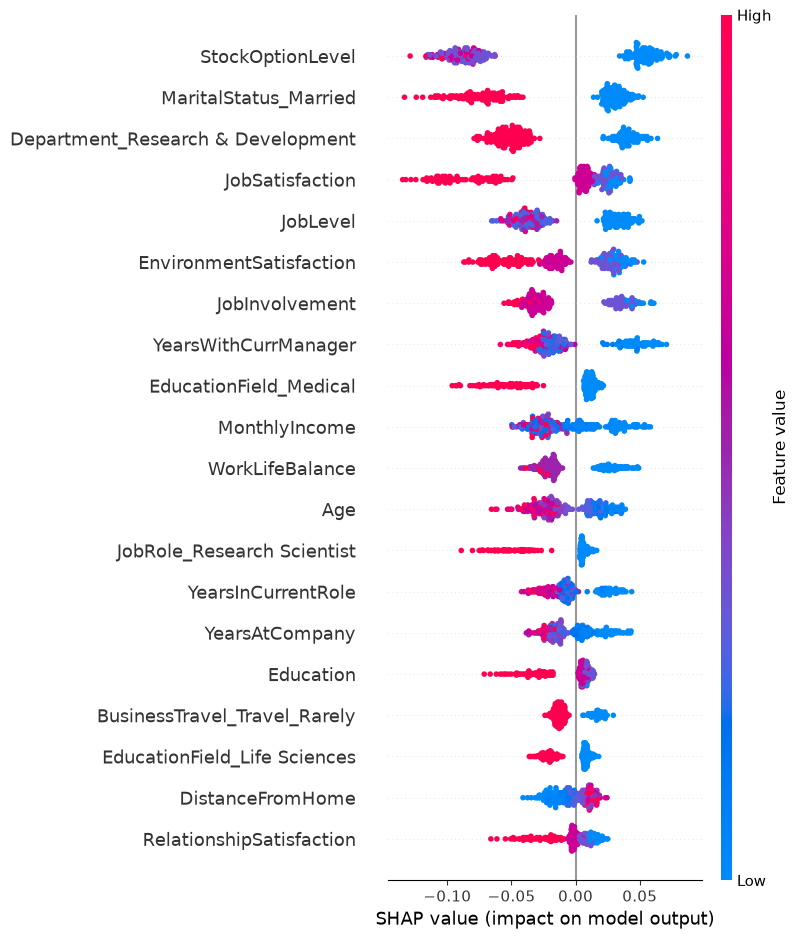

In [8]:
import shap

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf_full = explainer_rf.shap_values(X_test_unscaled)

print(shap_values_rf_full.shape)  # expect (n_samples, n_features, 2)

# We only care about class 1 (Attrition = Yes) - slice it out now, once, for everything downstream
shap_values_rf = shap_values_rf_full[:, :, 1]
print(shap_values_rf.shape)  # expect (n_samples, n_features)

shap.summary_plot(shap_values_rf, X_test_unscaled)

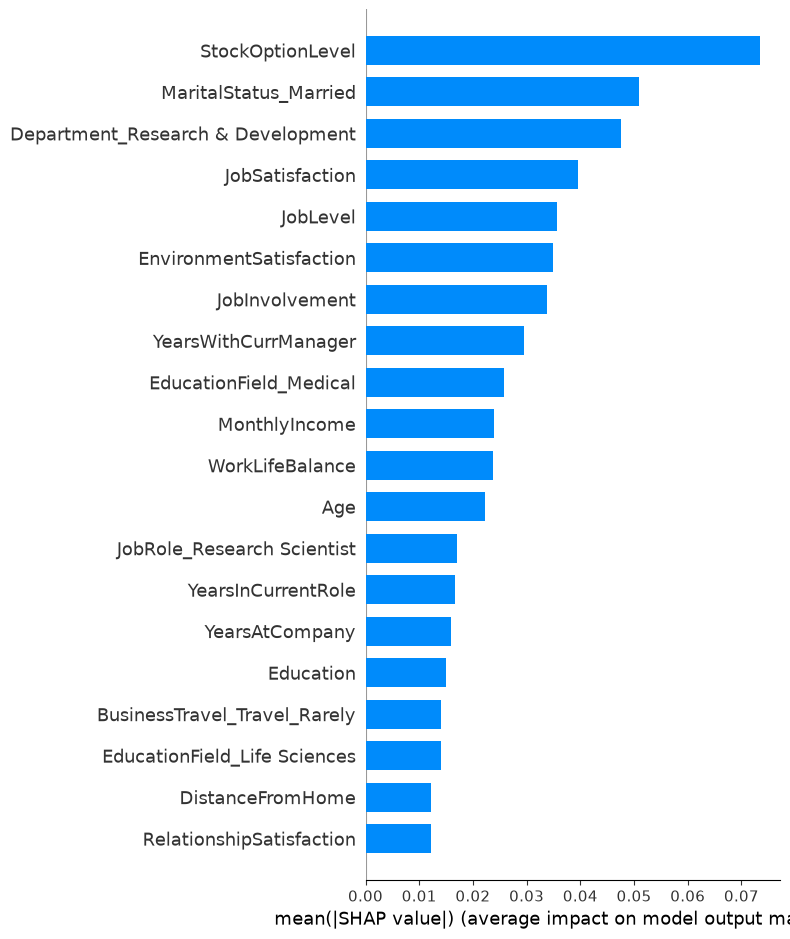

In [9]:
shap.summary_plot(shap_values_rf, X_test_unscaled, plot_type='bar')

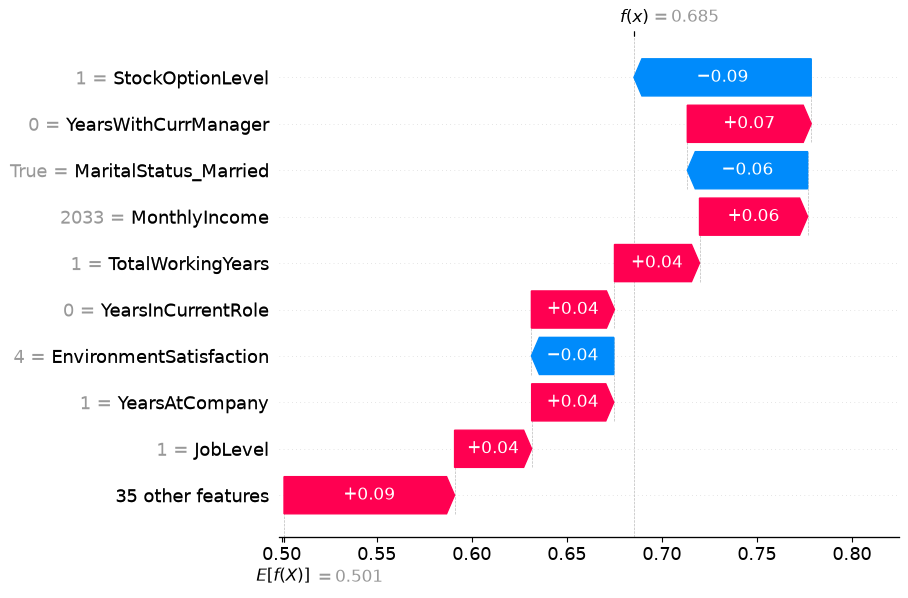

In [10]:
idx = 0  # pick any test set row index

base_value = explainer_rf.expected_value
# expected_value may also be an array of 2 (one per class) in this shap version - handle both cases
if hasattr(base_value, "__len__"):
    base_value = base_value[1]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[idx],
        base_values=base_value,
        data=X_test_unscaled.iloc[idx].values,
        feature_names=X_test_unscaled.columns.tolist()
    )
)

In [11]:
y_pred_rf = rf.predict(X_test_unscaled)
y_proba_rf = rf.predict_proba(X_test_unscaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.8061224489795918
Precision: 0.375
Recall: 0.3191489361702128
F1: 0.3448275862068966
ROC-AUC: 0.7309845809285899


In [13]:
import os
import tensorflow as tf
os.environ['PYTHONHASHSEED'] = '42'
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

nn = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6563 - loss: 0.6147 - val_accuracy: 0.5139 - val_loss: 0.7036
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7324 - loss: 0.5418 - val_accuracy: 0.7620 - val_loss: 0.5508
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7724 - loss: 0.4781 - val_accuracy: 0.8785 - val_loss: 0.3904
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8041 - loss: 0.4415 - val_accuracy: 0.9089 - val_loss: 0.2944
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8440 - loss: 0.3951 - val_accuracy: 0.9342 - val_loss: 0.2185
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8434 - loss: 0.3686 - val_accuracy: 0.9392 - val_loss: 0.1837
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8592 - loss: 0.3497 - val_accuracy: 0.9418 - val_loss: 0.1604
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8757 - loss: 0.3462 - val_accuracy: 0.9468 - v

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 3s 504us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 3s 472us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 774us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 4s 543us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 765us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 749us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 752us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 731us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 765us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 730us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 6s 842us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 5s 751us/step
1/1 

C:\Users\Devanshi\AppData\Local\Temp\ipykernel_7264\1952207063.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nn, sample_test)


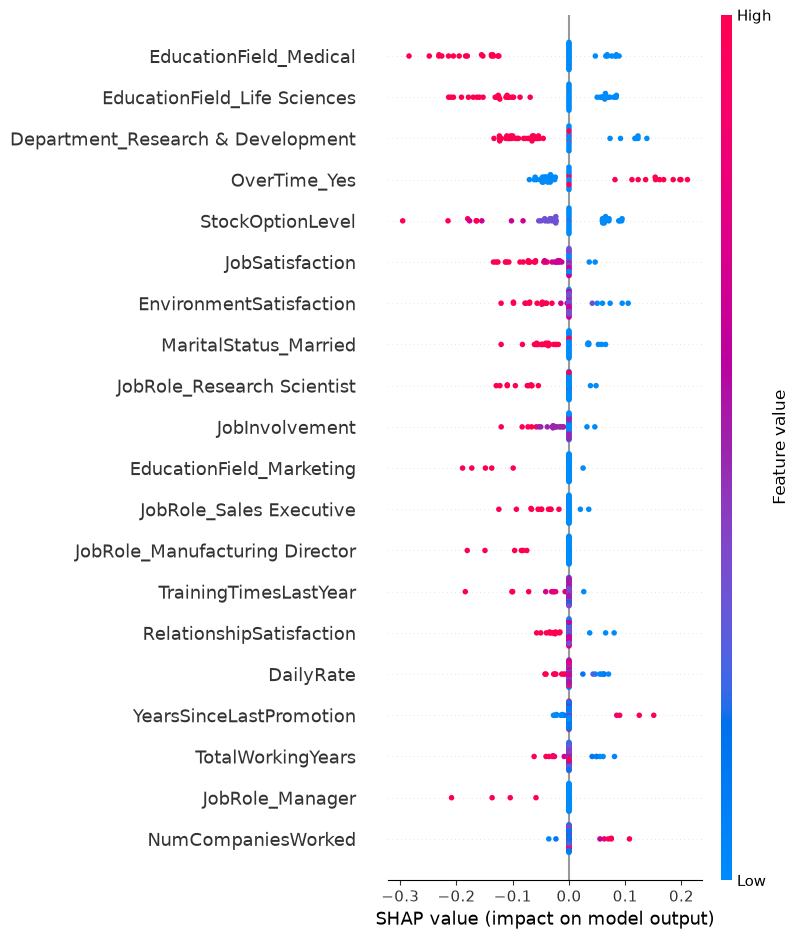

In [16]:
sample_test = X_test_scaled.iloc[:50]

background = shap.sample(X_train_scaled, 100)
explainer_nn = shap.KernelExplainer(nn.predict, background)
shap_values_nn = explainer_nn.shap_values(sample_test)
shap_values_nn = np.array(shap_values_nn)
print(shap_values_nn.shape)

if shap_values_nn.ndim == 3:
    shap_values_nn = shap_values_nn[:, :, 0]

shap.summary_plot(shap_values_nn, sample_test)

In [17]:
y_proba_nn = nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1:", f1_score(y_test, y_pred_nn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nn))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.8571428571428571
Precision: 0.5714285714285714
Recall: 0.425531914893617
F1: 0.4878048780487805
ROC-AUC: 0.7385649065380309


In [18]:
print(confusion_matrix(y_test, y_pred_nn))
# compare against confusion_matrix(y_test, y_pred_lr) from Cell 5 — should be [[232,15],[27,20]] if truly coincidental

[[232  15]
 [ 27  20]]


In [19]:
joblib.dump(logreg, '../models/logreg.pkl')
joblib.dump(rf, '../models/random_forest.pkl')
nn.save('../models/neural_network.keras')

# Save SHAP background + explainer-relevant data so we don't recompute everything in the app later
joblib.dump(X_test_unscaled, '../models/X_test_unscaled_for_shap.pkl')
joblib.dump(X_test_scaled, '../models/X_test_scaled_for_shap.pkl')

print("All models saved.")

All models saved.
